<div style="display:flex; justify-content:space-between; align-items:center; width:100%; margin:8px 0 24px 0;">
  <div style="text-align:left;">
    <img src="https://www.ec-nantes.fr/medias/photo/logocn-rvb_1648479844750-png?ID_FICHE=178994&amp;INLINE=FALSE" alt="Centrale Nantes" style="height:72px; width:auto;">
  </div>
  <div style="text-align:right; font-size:18px; font-weight:600; color:#17324d; line-height:1.35;">
    MSc. CORO DASSIP
  </div>
</div>

<div style="border:2px solid #333; padding:14px 20px; margin:15px auto 25px auto; width:85%; max-width:900px; box-sizing:border-box; text-align:center;">
  <h1 style="margin:0;"><b>Prompt Engineering for Unsupervised Audio Classification Using CLAP</b></h1>
</div>

## 0. Setup

In [3]:
from pathlib import Path
import time
import urllib.request
import zipfile

import laion_clap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import scipy
import torch
from scipy.stats import pearsonr, spearmanr
from tqdm import tqdm

np.set_printoptions(precision=4, suppress=True)

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

## 1. Data and Output Paths

In [4]:
# The notebook is stored in Projects/Prompt_Engineering_Audio_Classification/notebooks/.
PROJECT_DIR = Path("..")
DATA_DIR = PROJECT_DIR / "data"
TABLE_DIR = PROJECT_DIR / "outputs" / "tables"
FIG_DIR = PROJECT_DIR / "outputs" / "figures"

for directory in (DATA_DIR, TABLE_DIR, FIG_DIR):
    directory.mkdir(parents=True, exist_ok=True)

ESC50_ZIP_URL = "https://github.com/karoldvl/ESC-50/archive/master.zip"
ESC50_ZIP = DATA_DIR / "ESC50.zip"
ESC50_FOLDER = DATA_DIR / "ESC-50-master"

print("Data directory:", DATA_DIR)
print("Table directory:", TABLE_DIR)
print("Figure directory:", FIG_DIR)

Data directory: ../data
Table directory: ../outputs/tables
Figure directory: ../outputs/figures


## 2. ESC-50 Dataset Preparation

In [5]:
if ESC50_FOLDER.exists():
    print("ESC-50 already available.")
else:
    print("Downloading ESC-50...")
    urllib.request.urlretrieve(ESC50_ZIP_URL, ESC50_ZIP)

    print("Extracting ESC-50...")
    with zipfile.ZipFile(ESC50_ZIP, "r") as zip_ref:
        zip_ref.extractall(DATA_DIR)

    if ESC50_ZIP.exists():
        ESC50_ZIP.unlink()

    print("ESC-50 downloaded and extracted.")

AUDIO_DIR = ESC50_FOLDER / "audio"
META_PATH = ESC50_FOLDER / "meta" / "esc50.csv"

if not AUDIO_DIR.exists() or not META_PATH.exists():
    raise FileNotFoundError("ESC-50 audio or metadata files are missing.")

print("Audio:", AUDIO_DIR)
print("Metadata:", META_PATH)

ESC-50 already available.
Audio: ../data/ESC-50-master/audio
Metadata: ../data/ESC-50-master/meta/esc50.csv


## 3. Dataset Exploration

In [6]:
meta = pd.read_csv(META_PATH)
classes = sorted(meta["category"].unique())

print("Dataset Summary")
print("---------------")
print("Audio files:", len(meta))
print("Classes:", len(classes))

display(meta.head())
print("First 10 classes:", classes[:10])

meta.head(20).to_csv(TABLE_DIR / "esc50_metadata_preview.csv", index=False)
pd.DataFrame({"class": classes}).to_csv(TABLE_DIR / "esc50_class_list.csv", index=False)

Dataset Summary
---------------
Audio files: 2000
Classes: 50


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


First 10 classes: ['airplane', 'breathing', 'brushing_teeth', 'can_opening', 'car_horn', 'cat', 'chainsaw', 'chirping_birds', 'church_bells', 'clapping']


## 4. CLAP Model Initialization

In [7]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = laion_clap.CLAP_Module(enable_fusion=False)
model.load_ckpt()
model = model.to(device)
model.eval()

print("CLAP model loaded successfully.")

## 5. Prompt Strategy Definition

In [8]:
# ============================================================
# CELL 7 — Prompt strategy definition
# ============================================================

PROMPT_TEMPLATES = {
    "class_only": "{}",
    "a_class": "a {}",
    "sound_of": "the sound of {}",
    "sound_of_a": "the sound of a {}",
    "audio_recording": "an audio recording of {}",
    "recording_sound": "a recording of the sound of {}",
    "sound_clip": "a sound clip of {}",
    "this_is_sound": "this is the sound of {}",
    "environmental_sound": "an environmental sound of {}",
    "heard_sound": "the sound of {} can be heard",
}

print("Number of prompt strategies:", len(PROMPT_TEMPLATES))
print("\nPrompt strategies:\n")

for name, template in PROMPT_TEMPLATES.items():
    print(f"{name:25s} → {template}")

Number of prompt strategies: 10

Prompt strategies:

class_only                → {}
a_class                   → a {}
sound_of                  → the sound of {}
sound_of_a                → the sound of a {}
audio_recording           → an audio recording of {}
recording_sound           → a recording of the sound of {}
sound_clip                → a sound clip of {}
this_is_sound             → this is the sound of {}
environmental_sound       → an environmental sound of {}
heard_sound               → the sound of {} can be heard


## 6. Zero-Shot Classification Framework

In [9]:
# ============================================================
# CELL 8 — Core evaluation functions
# ============================================================

def clean_class_name(class_name):
    """Convert ESC-50 class labels into natural text."""
    return class_name.replace("_", " ")


def normalize(x):
    """L2-normalize embeddings. Dot product then equals cosine similarity."""
    return x / x.norm(dim=-1, keepdim=True)


def get_text_embeddings(model, classes, template, device):
    """Generate text prompts and compute CLAP text embeddings."""
    prompts = [template.format(clean_class_name(c)) for c in classes]

    with torch.no_grad():
        text_embed = model.get_text_embedding(prompts, use_tensor=True)

    text_embed = normalize(text_embed.to(device))
    return prompts, text_embed


def get_audio_embedding(model, audio_path, device):
    """Compute CLAP audio embedding for one audio file."""
    with torch.no_grad():
        audio_embed = model.get_audio_embedding_from_filelist(
            x=[str(audio_path)],
            use_tensor=True
        )

    audio_embed = normalize(audio_embed.to(device))
    return audio_embed


def evaluate_template(model, meta, classes, template, strategy_name, device, top_k=10):
    """
    Evaluate one prompt strategy on ESC-50.

    For each audio sample, this function stores:
    - predicted Top-1 class
    - correctness
    - Top-1 and Top-2 similarity scores
    - confidence margin
    - Top-k ranked classes and similarity scores up to k=10
    """

    _, text_embed = get_text_embeddings(model, classes, template, device)

    records = []
    start_time = time.time()
    top_k = min(top_k, len(classes))

    for _, row in tqdm(meta.iterrows(), total=len(meta), desc=strategy_name):
        audio_path = AUDIO_DIR / row["filename"]
        true_class = row["category"]

        audio_embed = get_audio_embedding(model, audio_path, device)
        similarity = (audio_embed @ text_embed.T).squeeze(0)

        top_values, top_indices = torch.topk(similarity, k=top_k)
        top_classes = [classes[idx.item()] for idx in top_indices]

        pred_class = top_classes[0]

        record = {
            "filename": row["filename"],
            "true_class": true_class,
            "predicted_class": pred_class,
            "correct": pred_class == true_class,
            "top1_similarity": top_values[0].item(),
            "top2_similarity": top_values[1].item(),
            "margin": top_values[0].item() - top_values[1].item(),
        }

        for rank in range(top_k):
            record[f"top{rank + 1}_class"] = top_classes[rank]
            record[f"top{rank + 1}_similarity"] = top_values[rank].item()

        records.append(record)

    elapsed = time.time() - start_time
    predictions_df = pd.DataFrame(records)
    accuracy = predictions_df["correct"].mean()

    return {
        "strategy": strategy_name,
        "template": template,
        "top1_accuracy": accuracy,
        "total_runtime_seconds": elapsed,
        "runtime_per_audio_seconds": elapsed / len(meta),
        "predictions": predictions_df,
    }


print("Core evaluation functions loaded successfully.")

Core evaluation functions loaded successfully.


## 7. Full Prompt Benchmark

In [10]:
# ============================================================
# CELL 9 — Full prompt benchmark
# ============================================================

all_results = []
all_predictions = {}

for strategy_name, template in PROMPT_TEMPLATES.items():

    result = evaluate_template(
        model=model,
        meta=meta,
        classes=classes,
        template=template,
        strategy_name=strategy_name,
        device=device,
        top_k=10
    )

    all_results.append({
        "strategy": result["strategy"],
        "template": result["template"],
        "top1_accuracy": result["top1_accuracy"],
        "total_runtime_seconds": result["total_runtime_seconds"],
        "runtime_per_audio_seconds": result["runtime_per_audio_seconds"],
    })

    all_predictions[strategy_name] = result["predictions"]

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values("top1_accuracy", ascending=False).reset_index(drop=True)
results_df.insert(0, "rank", range(1, len(results_df) + 1))
results_df["top1_accuracy_percent"] = results_df["top1_accuracy"] * 100

print("\nFINAL BENCHMARK")
print("----------------")
display(results_df)

results_path = TABLE_DIR / "prompt_accuracy_results.csv"
results_df.to_csv(results_path, index=False)

print("\nSaved:")
print(results_path)

heard_sound: 100%|██████████| 2000/2000 [24:41<00:00,  1.35it/s]



FINAL BENCHMARK
----------------


,rank,strategy,template,top1_accuracy,total_runtime_seconds,runtime_per_audio_seconds,top1_accuracy_percent
0,1,audio_recording,an audio recording of {},0.9115,1406.444404,0.703222,91.15
1,2,sound_clip,a sound clip of {},0.8760,1476.549186,0.738275,87.60
2,3,recording_sound,a recording of the sound of {},0.8755,1498.871469,0.749436,87.55
3,4,a_class,a {},0.8700,1407.558645,0.703779,87.00
4,5,heard_sound,the sound of {} can be heard,0.8510,1481.944859,0.740972,85.10
5,6,sound_of_a,the sound of a {},0.8490,1384.139359,0.692070,84.90
6,7,sound_of,the sound of {},0.8375,1390.924502,0.695462,83.75
7,8,this_is_sound,this is the sound of {},0.8310,1536.947323,0.768474,83.10
8,9,class_only,{},0.8305,1451.539492,0.725770,83.05
9,10,environmental_sound,an environmental sound of {},0.8185,1498.545165,0.749273,81.85



Saved:
../outputs/tables/prompt_accuracy_results.csv


### Reference result from the submitted experiment

The submitted notebook recorded **91.15% Top-1 accuracy** for the best prompt, compared with **83.05%** for the class-only baseline. A fresh execution recomputes every value.

## 8. Best Prompt and Class-wise Accuracy

In [11]:
# ============================================================
# CELL 10 — Recover best prompt predictions
# ============================================================

best_strategy = results_df.iloc[0]["strategy"]
best_template = results_df.iloc[0]["template"]
best_accuracy = results_df.iloc[0]["top1_accuracy"]

print("Best strategy:", best_strategy)
print("Best template:", best_template)
print(f"Best Top-1 accuracy: {best_accuracy * 100:.2f}%")

best_predictions_df = all_predictions[best_strategy].copy()

best_predictions_path = TABLE_DIR / "predictions_best_prompt.csv"
best_predictions_df.to_csv(best_predictions_path, index=False)

print("\nSaved best-prompt predictions:")
print(best_predictions_path)

Best strategy: audio_recording
Best template: an audio recording of {}
Best Top-1 accuracy: 91.15%

Saved best-prompt predictions:
../outputs/tables/predictions_best_prompt.csv


In [12]:
# ============================================================
# CELL 11 — Class-wise accuracy for best prompt
# ============================================================

classwise_df = (
    best_predictions_df
    .groupby("true_class")
    .agg(
        samples=("correct", "size"),
        correct=("correct", "sum"),
        accuracy=("correct", "mean")
    )
    .reset_index()
)

classwise_df["accuracy_percent"] = classwise_df["accuracy"] * 100
classwise_df = classwise_df.sort_values("accuracy_percent", ascending=True).reset_index(drop=True)

print("Lowest-performing classes:")
display(classwise_df.head(10))

print("Highest-performing classes:")
display(classwise_df.tail(10).sort_values("accuracy_percent", ascending=False))

classwise_path = TABLE_DIR / "classwise_accuracy.csv"
classwise_df.to_csv(classwise_path, index=False)

print("\nSaved:")
print(classwise_path)

Lowest-performing classes:


,true_class,samples,correct,accuracy,accuracy_percent
0,insects,40,5,0.125,12.5
1,footsteps,40,23,0.575,57.5
2,wind,40,23,0.575,57.5
3,washing_machine,40,28,0.700,70.0
4,rooster,40,29,0.725,72.5
5,airplane,40,32,0.800,80.0
6,helicopter,40,32,0.800,80.0
7,crickets,40,32,0.800,80.0
8,rain,40,32,0.800,80.0
9,engine,40,33,0.825,82.5


Highest-performing classes:


,true_class,samples,correct,accuracy,accuracy_percent
40,cow,40,40,1.0,100.0
41,crow,40,40,1.0,100.0
42,crying_baby,40,40,1.0,100.0
43,dog,40,40,1.0,100.0
44,laughing,40,40,1.0,100.0
45,keyboard_typing,40,40,1.0,100.0
46,door_wood_knock,40,40,1.0,100.0
47,fireworks,40,40,1.0,100.0
48,brushing_teeth,40,40,1.0,100.0
49,glass_breaking,40,40,1.0,100.0



Saved:
../outputs/tables/classwise_accuracy.csv


## 9. Prompt Strategy Comparison

Prompt strategy comparison table


,Prompt Strategy,Top-1 Accuracy (%)
0,Class Only (Baseline),83.05
1,Environmental Sound,81.85
2,This Is Sound,83.10
3,Sound Of,83.75
4,Sound Of A,84.90
5,Heard Sound,85.10
6,A Class,87.00
7,Recording Sound,87.55
8,Sound Clip,87.60
9,Audio Recording,91.15


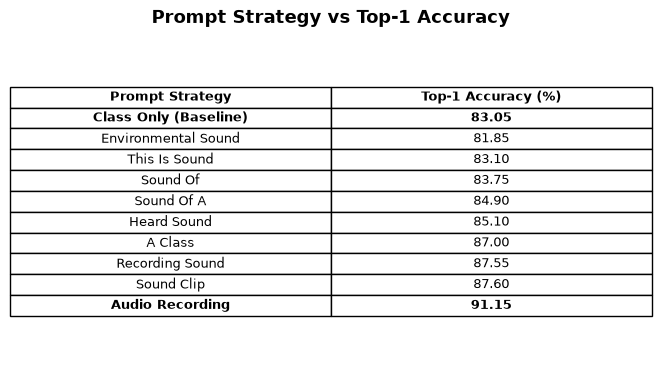

Saved:
../outputs/tables/prompt_strategy_comparison_table.csv
../outputs/figures/prompt_strategy_comparison_table.png


In [13]:
# ============================================================
# CELL 12 — Export prompt-strategy comparison as table figure
# ============================================================

# Human-friendly names for report / slides
STRATEGY_DISPLAY_NAMES = {
    "class_only": "Class Only (Baseline)",
    "a_class": "A Class",
    "sound_of": "Sound Of",
    "sound_of_a": "Sound Of A",
    "audio_recording": "Audio Recording",
    "recording_sound": "Recording Sound",
    "sound_clip": "Sound Clip",
    "this_is_sound": "This Is Sound",
    "environmental_sound": "Environmental Sound",
    "heard_sound": "Heard Sound",
}

prompt_table_df = results_df.copy()
prompt_table_df["Prompt Strategy"] = prompt_table_df["strategy"].map(STRATEGY_DISPLAY_NAMES).fillna(prompt_table_df["strategy"])
prompt_table_df["Top-1 Accuracy (%)"] = (prompt_table_df["top1_accuracy"] * 100).round(2)

# Put baseline first, then remaining strategies from low to high accuracy, as used in the report.
baseline_df = prompt_table_df[prompt_table_df["strategy"] == "class_only"]
other_df = prompt_table_df[prompt_table_df["strategy"] != "class_only"].sort_values("Top-1 Accuracy (%)", ascending=True)
prompt_table_display_df = pd.concat([baseline_df, other_df], ignore_index=True)
prompt_table_display_df = prompt_table_display_df[["Prompt Strategy", "Top-1 Accuracy (%)"]]

print("Prompt strategy comparison table")
display(prompt_table_display_df)

prompt_table_path = TABLE_DIR / "prompt_strategy_comparison_table.csv"
prompt_table_display_df.to_csv(prompt_table_path, index=False)

# Export as clean table image
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.axis("off")

plot_table = prompt_table_display_df.copy()
plot_table["Top-1 Accuracy (%)"] = plot_table["Top-1 Accuracy (%)"].map(lambda x: f"{x:.2f}")

table = ax.table(
    cellText=plot_table.values,
    colLabels=plot_table.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1.15, 1.25)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("black")
    if row == 0:
        cell.set_text_props(weight="bold")
    # Highlight baseline and best prompt
    if row > 0:
        strategy = prompt_table_display_df.iloc[row - 1]["Prompt Strategy"]
        if strategy == "Class Only (Baseline)" or strategy == "Audio Recording":
            cell.set_text_props(weight="bold")

ax.set_title("Prompt Strategy vs Top-1 Accuracy", fontsize=13, weight="bold", pad=12)

prompt_table_fig_path = FIG_DIR / "prompt_strategy_comparison_table.png"
plt.savefig(prompt_table_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:")
print(prompt_table_path)
print(prompt_table_fig_path)


## 10. Class-wise Accuracy Summary

Lowest-performing classes


,Class,Accuracy (%)
0,Insects,12.5
1,Footsteps,57.5
2,Wind,57.5
3,Washing Machine,70.0
4,Rooster,72.5
5,Airplane,80.0
6,Helicopter,80.0
7,Crickets,80.0
8,Rain,80.0
9,Engine,82.5


Highest-performing classes


,Class,Accuracy (%)
40,Cow,100.0
41,Crow,100.0
42,Crying Baby,100.0
43,Dog,100.0
44,Laughing,100.0
45,Keyboard Typing,100.0
46,Door Wood Knock,100.0
47,Fireworks,100.0
48,Brushing Teeth,100.0
49,Glass Breaking,100.0


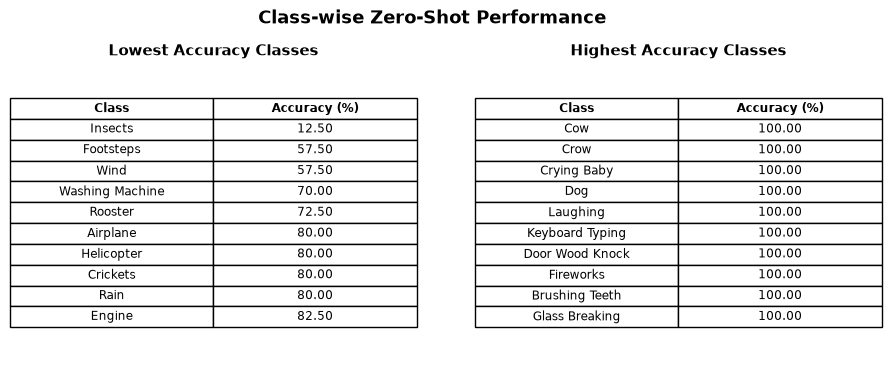

Saved:
../outputs/tables/classwise_lowest_highest_accuracy.csv
../outputs/figures/classwise_accuracy_tables.png


In [14]:
# ============================================================
# CELL 13 — Export class-wise accuracy table figure
# ============================================================

lowest_df = classwise_df.head(10).copy()
highest_df = classwise_df.tail(10).sort_values("accuracy_percent", ascending=False).copy()

lowest_display = pd.DataFrame({
    "Class": lowest_df["true_class"].apply(clean_class_name).str.title(),
    "Accuracy (%)": lowest_df["accuracy_percent"].round(2)
})

highest_display = pd.DataFrame({
    "Class": highest_df["true_class"].apply(clean_class_name).str.title(),
    "Accuracy (%)": highest_df["accuracy_percent"].round(2)
})

print("Lowest-performing classes")
display(lowest_display)
print("Highest-performing classes")
display(highest_display)

classwise_summary_path = TABLE_DIR / "classwise_lowest_highest_accuracy.csv"
classwise_summary_df = pd.concat(
    [
        lowest_display.assign(Group="Lowest-performing"),
        highest_display.assign(Group="Highest-performing"),
    ],
    ignore_index=True
)
classwise_summary_df.to_csv(classwise_summary_path, index=False)

# Side-by-side table image
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, df, title in zip(
    axes,
    [lowest_display, highest_display],
    ["Lowest Accuracy Classes", "Highest Accuracy Classes"]
):
    ax.axis("off")
    plot_df = df.copy()
    plot_df["Accuracy (%)"] = plot_df["Accuracy (%)"].map(lambda x: f"{x:.2f}")
    table = ax.table(
        cellText=plot_df.values,
        colLabels=plot_df.columns,
        cellLoc="center",
        colLoc="center",
        loc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8.5)
    table.scale(1.05, 1.25)
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("black")
        if row == 0:
            cell.set_text_props(weight="bold")
    ax.set_title(title, fontsize=11, weight="bold", pad=8)

fig.suptitle("Class-wise Zero-Shot Performance", fontsize=13, weight="bold", y=1.03)
classwise_fig_path = FIG_DIR / "classwise_accuracy_tables.png"
plt.savefig(classwise_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:")
print(classwise_summary_path)
print(classwise_fig_path)


## 11. Main Benchmark Summary

In [15]:
# ============================================================
# CELL 14 — Main benchmark summary
# ============================================================

print("Best prompt strategy:", STRATEGY_DISPLAY_NAMES.get(best_strategy, best_strategy))
print("Best prompt template:", best_template)
print(f"Top-1 accuracy: {best_accuracy * 100:.2f}%")

baseline_acc = results_df.loc[results_df["strategy"] == "class_only", "top1_accuracy"].iloc[0]
print(f"Class-only baseline: {baseline_acc * 100:.2f}%")
print(f"Improvement: {(best_accuracy - baseline_acc) * 100:.2f} percentage points")


Best prompt strategy: Audio Recording
Best prompt template: an audio recording of {}
Top-1 accuracy: 91.15%
Class-only baseline: 83.05%
Improvement: 8.10 percentage points


## 12. Top-k Accuracy

In [16]:
# ============================================================
# CELL 15 — Top-k accuracy from Top-1 to Top-10
# ============================================================

topk_rows = []

for k in range(1, 11):
    topk_cols = [f"top{i}_class" for i in range(1, k + 1)]

    correct_topk = best_predictions_df.apply(
        lambda row: row["true_class"] in [row[col] for col in topk_cols],
        axis=1
    )

    topk_rows.append({
        "Top-k": f"Top-{k}",
        "Accuracy": correct_topk.mean(),
        "Accuracy (%)": correct_topk.mean() * 100
    })

topk_df = pd.DataFrame(topk_rows)

print("Top-k accuracy table")
display(topk_df[["Top-k", "Accuracy (%)"]])

topk_path = TABLE_DIR / "topk_accuracy.csv"
topk_df.to_csv(topk_path, index=False)
print("Saved:", topk_path)


Top-k accuracy table


,Top-k,Accuracy (%)
0,Top-1,91.15
1,Top-2,95.80
2,Top-3,97.45
3,Top-4,98.60
4,Top-5,99.00
5,Top-6,99.10
6,Top-7,99.15
7,Top-8,99.40
8,Top-9,99.40
9,Top-10,99.55


Saved: ../outputs/tables/topk_accuracy.csv


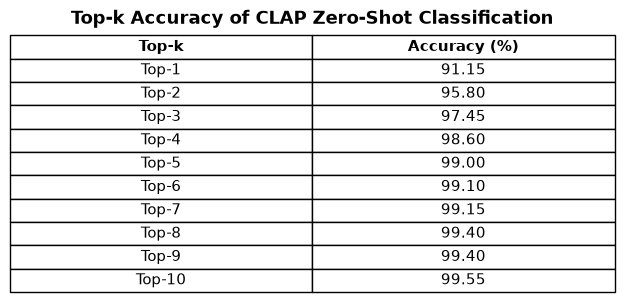

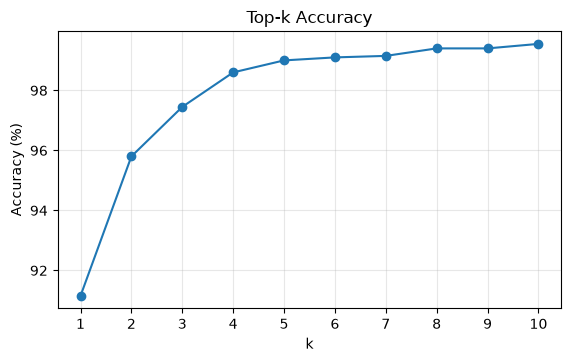

Saved:
../outputs/figures/topk_accuracy_table.png
../outputs/figures/topk_accuracy_line.png


In [17]:
# ============================================================
# CELL 16 — Export Top-k accuracy as table and line figure
# ============================================================

# Table figure
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.axis("off")

plot_table = topk_df[["Top-k", "Accuracy (%)"]].copy()
plot_table["Accuracy (%)"] = plot_table["Accuracy (%)"].map(lambda x: f"{x:.2f}")

table = ax.table(
    cellText=plot_table.values,
    colLabels=plot_table.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.4)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("black")
    if row == 0:
        cell.set_text_props(weight="bold")

ax.set_title("Top-k Accuracy of CLAP Zero-Shot Classification", fontsize=13, weight="bold", pad=12)

topk_table_fig_path = FIG_DIR / "topk_accuracy_table.png"
plt.savefig(topk_table_fig_path, dpi=300, bbox_inches="tight")
plt.show()

# Line figure for optional presentation use
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(range(1, 11), topk_df["Accuracy (%)"], marker="o")
ax.set_xlabel("k")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Top-k Accuracy")
ax.set_xticks(range(1, 11))
ax.grid(True, alpha=0.3)

topk_line_fig_path = FIG_DIR / "topk_accuracy_line.png"
plt.savefig(topk_line_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:")
print(topk_table_fig_path)
print(topk_line_fig_path)


## 13. AudioSet Metadata Analysis

This analysis compares class-wise ESC-50 accuracy with manually curated AudioSet metadata for the corresponding sound categories. Pearson and Spearman correlations are computed for AudioSet quality scores and log-scaled video counts.

Matched classes: 50 / 50


,true_class,accuracy_percent,AudioSet Label,AudioSet Quality (%),AudioSet Videos
0,insects,12.5,Insect,80,3164
1,footsteps,57.5,"Walk, footsteps",90,1683
2,wind,57.5,Wind,100,6805
3,washing_machine,70.0,Washing machine,80,1053
4,rooster,72.5,"Chicken, rooster",90,6352
5,airplane,80.0,Aircraft,89,5476
6,helicopter,80.0,Helicopter,100,3698
7,crickets,80.0,Cricket,100,859
8,rain,80.0,Rain,80,4951
9,engine,82.5,Engine,100,16245


,Variable,Pearson r,Pearson p-value,Spearman rho,Spearman p-value
0,AudioSet Quality (%),0.080940,0.576318,0.107285,0.458342
1,log10(AudioSet Videos),-0.180547,0.209585,-0.066446,0.646617


Saved:
../outputs/tables/audioset_all50_metadata_vs_esc50_accuracy.csv
../outputs/tables/audioset_all50_correlation_summary.csv


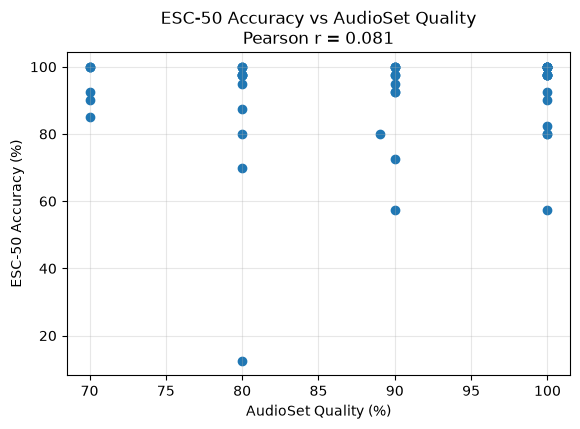

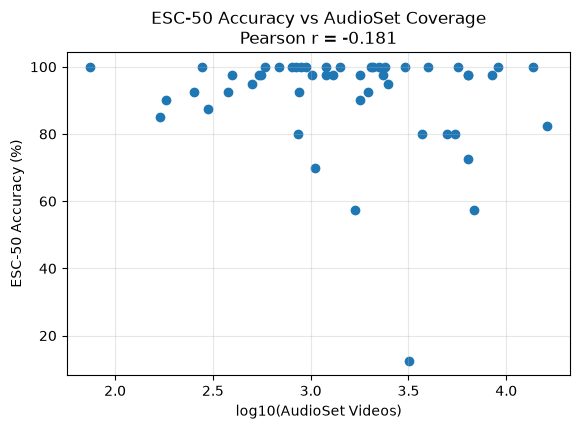

Saved figures:
../outputs/figures/all50_esc50_accuracy_vs_audioset_quality.png
../outputs/figures/all50_esc50_accuracy_vs_audioset_coverage.png

REPORT VALUES
Pearson r: ESC-50 Accuracy vs AudioSet Quality = 0.081, p = 0.576
Pearson r: ESC-50 Accuracy vs log10(AudioSet Videos) = -0.181, p = 0.210
Spearman rho: ESC-50 Accuracy vs AudioSet Quality = 0.107, p = 0.458
Spearman rho: ESC-50 Accuracy vs log10(AudioSet Videos) = -0.066, p = 0.647


In [18]:
# ============================================================
# 19 AudioSet correlation analysis across all 50 ESC-50 classes
# ============================================================

# ------------------------------------------------------------
# ESC-50 to AudioSet label mapping
# ------------------------------------------------------------
ESC50_TO_AUDIOSET_50 = {
    "airplane": "Aircraft",
    "breathing": "Breathing",
    "brushing_teeth": "Toothbrush",
    "can_opening": "Opening or closing",
    "car_horn": "Car horn, honking",
    "cat": "Cat",
    "chainsaw": "Chainsaw",
    "chirping_birds": "Bird vocalization, bird call, bird song",
    "church_bells": "Church bell",
    "clapping": "Clapping",
    "clock_alarm": "Alarm clock",
    "clock_tick": "Tick-tock",
    "coughing": "Cough",
    "cow": "Moo",
    "crackling_fire": "Crackle",
    "crickets": "Cricket",
    "crow": "Crow",
    "crying_baby": "Baby cry, infant cry",
    "dog": "Dog",
    "door_wood_creaks": "Creak",
    "door_wood_knock": "Knock",
    "drinking_sipping": "Drinking, sipping",
    "engine": "Engine",
    "fireworks": "Fireworks",
    "footsteps": "Walk, footsteps",
    "frog": "Croak",
    "glass_breaking": "Glass",
    "hand_saw": "Sawing",
    "helicopter": "Helicopter",
    "hen": "Cluck",
    "insects": "Insect",
    "keyboard_typing": "Computer keyboard",
    "laughing": "Laughter",
    "mouse_click": "Clicking",
    "pig": "Oink",
    "pouring_water": "Pour",
    "rain": "Rain",
    "rooster": "Chicken, rooster",
    "sea_waves": "Waves, surf",
    "sheep": "Bleat",
    "siren": "Siren",
    "sneezing": "Sneeze",
    "snoring": "Snoring",
    "thunderstorm": "Thunder",
    "toilet_flush": "Toilet flush",
    "train": "Rail transport",
    "vacuum_cleaner": "Vacuum cleaner",
    "washing_machine": "Washing machine",
    "water_drops": "Drip",
    "wind": "Wind",
}

# ------------------------------------------------------------
# Manual correction table from AudioSet page text
# These are taken from the AudioSet dataset page.
# ------------------------------------------------------------
AUDIOSET_50_METADATA = pd.DataFrame([
    ["airplane", "Aircraft", 89, 5476],
    ["breathing", "Breathing", 80, 1015],
    ["brushing_teeth", "Toothbrush", 70, 74],
    ["can_opening", "Opening or closing", 80, 6367],
    ["car_horn", "Car horn, honking", 80, 504],
    ["cat", "Cat", 100, 3964],
    ["chainsaw", "Chainsaw", 100, 1787],
    ["chirping_birds", "Bird vocalization, bird call, bird song", 100, 6372],
    ["church_bells", "Church bell", 90, 1202],
    ["clapping", "Clapping", 80, 1416],
    ["clock_alarm", "Alarm clock", 70, 582],
    ["clock_tick", "Tick-tock", 70, 253],
    ["coughing", "Cough", 100, 871],
    ["cow", "Moo", 90, 689],
    ["crackling_fire", "Crackle", 80, 554],
    ["crickets", "Cricket", 100, 859],
    ["crow", "Crow", 80, 943],
    ["crying_baby", "Baby cry, infant cry", 100, 2390],
    ["dog", "Dog", 100, 13705],
    ["door_wood_creaks", "Creak", 80, 544],
    ["door_wood_knock", "Knock", 70, 279],
    ["drinking_sipping", "Drinking, sipping", 70, 170],
    ["engine", "Engine", 100, 16245],
    ["fireworks", "Fireworks", 100, 3051],
    ["footsteps", "Walk, footsteps", 90, 1683],
    ["frog", "Croak", 90, 380],
    ["glass_breaking", "Glass", 90, 845],
    ["hand_saw", "Sawing", 100, 804],
    ["helicopter", "Helicopter", 100, 3698],
    ["hen", "Cluck", 90, 2483],
    ["insects", "Insect", 80, 3164],
    ["keyboard_typing", "Computer keyboard", 100, 2042],
    ["laughing", "Laughter", 100, 5696],
    ["mouse_click", "Clicking", 70, 183],
    ["pig", "Oink", 100, 1784],
    ["pouring_water", "Pour", 90, 394],
    ["rain", "Rain", 80, 4951],
    ["rooster", "Chicken, rooster", 90, 6352],
    ["sea_waves", "Waves, surf", 80, 891],
    ["sheep", "Bleat", 100, 2078],
    ["siren", "Siren", 100, 8498],
    ["sneezing", "Sneeze", 100, 1200],
    ["snoring", "Snoring", 100, 2334],
    ["thunderstorm", "Thunder", 90, 1296],
    ["toilet_flush", "Toilet flush", 90, 2243],
    ["train", "Rail transport", 100, 9052],
    ["vacuum_cleaner", "Vacuum cleaner", 90, 1974],
    ["washing_machine", "Washing machine", 80, 1053],
    ["water_drops", "Drip", 80, 297],
    ["wind", "Wind", 100, 6805],
], columns=[
    "esc50_key",
    "AudioSet Label",
    "AudioSet Quality (%)",
    "AudioSet Videos"
])

# ------------------------------------------------------------
# Prepare class-wise accuracy dataframe
# ------------------------------------------------------------
def normalize_class_name(x):
    return str(x).strip().lower().replace(" ", "_").replace("-", "_")

classwise_tmp = classwise_df.copy()

if "true_class" not in classwise_tmp.columns:
    raise ValueError("classwise_df must contain a 'true_class' column.")

if "accuracy_percent" not in classwise_tmp.columns:
    # Try common alternatives
    possible_cols = [c for c in classwise_tmp.columns if "acc" in c.lower()]
    if not possible_cols:
        raise ValueError("Could not find accuracy column in classwise_df.")
    classwise_tmp = classwise_tmp.rename(columns={possible_cols[0]: "accuracy_percent"})

classwise_tmp["esc50_key"] = classwise_tmp["true_class"].apply(normalize_class_name)

# ------------------------------------------------------------
# Merge ESC-50 accuracy with AudioSet metadata
# ------------------------------------------------------------
audioset_all50_df = classwise_tmp.merge(
    AUDIOSET_50_METADATA,
    on="esc50_key",
    how="left"
)

missing = audioset_all50_df[audioset_all50_df["AudioSet Label"].isna()]
if len(missing) > 0:
    print("Missing classes:")
    display(missing[["true_class", "esc50_key"]])
    raise ValueError("Some ESC-50 classes are missing AudioSet metadata.")

audioset_all50_df["log10_AudioSet_Videos"] = np.log10(
    audioset_all50_df["AudioSet Videos"]
)

# ------------------------------------------------------------
# Correlation analysis
# ------------------------------------------------------------
quality_pearson, quality_p = pearsonr(
    audioset_all50_df["accuracy_percent"],
    audioset_all50_df["AudioSet Quality (%)"]
)

videos_pearson, videos_p = pearsonr(
    audioset_all50_df["accuracy_percent"],
    audioset_all50_df["log10_AudioSet_Videos"]
)

quality_spearman, quality_sp = spearmanr(
    audioset_all50_df["accuracy_percent"],
    audioset_all50_df["AudioSet Quality (%)"]
)

videos_spearman, videos_sp = spearmanr(
    audioset_all50_df["accuracy_percent"],
    audioset_all50_df["log10_AudioSet_Videos"]
)

corr_summary_df = pd.DataFrame({
    "Variable": [
        "AudioSet Quality (%)",
        "log10(AudioSet Videos)"
    ],
    "Pearson r": [
        quality_pearson,
        videos_pearson
    ],
    "Pearson p-value": [
        quality_p,
        videos_p
    ],
    "Spearman rho": [
        quality_spearman,
        videos_spearman
    ],
    "Spearman p-value": [
        quality_sp,
        videos_sp
    ],
})

print("Matched classes:", len(audioset_all50_df), "/ 50")
display(audioset_all50_df[[
    "true_class",
    "accuracy_percent",
    "AudioSet Label",
    "AudioSet Quality (%)",
    "AudioSet Videos"
]])

display(corr_summary_df)

# ------------------------------------------------------------
# Save tables
# ------------------------------------------------------------
all50_path = TABLE_DIR / "audioset_all50_metadata_vs_esc50_accuracy.csv"
corr_path = TABLE_DIR / "audioset_all50_correlation_summary.csv"

audioset_all50_df.to_csv(all50_path, index=False)
corr_summary_df.to_csv(corr_path, index=False)

print("Saved:")
print(all50_path)
print(corr_path)

# ------------------------------------------------------------
# Scatter plots
# ------------------------------------------------------------
plt.figure(figsize=(6.5, 4.2))
plt.scatter(
    audioset_all50_df["AudioSet Quality (%)"],
    audioset_all50_df["accuracy_percent"]
)
plt.xlabel("AudioSet Quality (%)")
plt.ylabel("ESC-50 Accuracy (%)")
plt.title(f"ESC-50 Accuracy vs AudioSet Quality\nPearson r = {quality_pearson:.3f}")
plt.grid(True, alpha=0.3)
quality_fig_path = FIG_DIR / "all50_esc50_accuracy_vs_audioset_quality.png"
plt.savefig(quality_fig_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6.5, 4.2))
plt.scatter(
    audioset_all50_df["log10_AudioSet_Videos"],
    audioset_all50_df["accuracy_percent"]
)
plt.xlabel("log10(AudioSet Videos)")
plt.ylabel("ESC-50 Accuracy (%)")
plt.title(f"ESC-50 Accuracy vs AudioSet Coverage\nPearson r = {videos_pearson:.3f}")
plt.grid(True, alpha=0.3)
coverage_fig_path = FIG_DIR / "all50_esc50_accuracy_vs_audioset_coverage.png"
plt.savefig(coverage_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figures:")
print(quality_fig_path)
print(coverage_fig_path)

print("\nREPORT VALUES")
print(f"Pearson r: ESC-50 Accuracy vs AudioSet Quality = {quality_pearson:.3f}, p = {quality_p:.3f}")
print(f"Pearson r: ESC-50 Accuracy vs log10(AudioSet Videos) = {videos_pearson:.3f}, p = {videos_p:.3f}")
print(f"Spearman rho: ESC-50 Accuracy vs AudioSet Quality = {quality_spearman:.3f}, p = {quality_sp:.3f}")
print(f"Spearman rho: ESC-50 Accuracy vs log10(AudioSet Videos) = {videos_spearman:.3f}, p = {videos_sp:.3f}")

#### Interpretation

The correlation analysis showed no meaningful relationship between ESC-50 accuracy and AudioSet metadata.

- Accuracy vs AudioSet Quality:
  - Pearson r = 0.081
  - Spearman rho = 0.107

- Accuracy vs AudioSet Videos:
  - Pearson r = -0.181
  - Spearman rho = -0.066

These results suggest that neither AudioSet quality scores nor the number of AudioSet videos alone explains the observed performance differences across ESC-50 classes.

The findings indicate that factors such as acoustic distinctiveness, intra-class variability, and audio–text semantic alignment are likely more important determinants of CLAP zero-shot classification performance.

## 14. Comparison with Published ESC-50 Classifiers

To place the CLAP results in context, the best-performing prompt strategy was compared with representative state-of-the-art methods reported on the ESC-50 benchmark.

The comparison includes:

- **AST (Audio Spectrogram Transformer)** [1]
- **HTS-AT (Hierarchical Token-Semantic Audio Transformer)** [2]
- **BEATs (Audio Pre-Training with Acoustic Tokenizers)** [3]

The reported accuracies were taken directly from the corresponding publications and were not recomputed in this project. In contrast, the CLAP result was obtained from the experiments conducted in this notebook using a strictly zero-shot evaluation protocol without task-specific training or fine-tuning.

This comparison highlights the trade-off between supervised models optimized for environmental sound classification and foundation models that can perform classification through natural-language prompting.

## References

[1] Gong, Y., Chung, Y.-A., & Glass, J. (2021). *AST: Audio Spectrogram Transformer*. Interspeech 2021.

[2] Chen, K. et al. (2022). *HTS-AT: A Hierarchical Token-Semantic Audio Transformer for Sound Classification and Detection*. arXiv:2202.00874.

[3] Chen, S. et al. (2023). *BEATs: Audio Pre-Training with Acoustic Tokenizers*. ICML 2023.

In [19]:
# ============================================================
# Phase 20 — Comparison with Published ESC-50 Classifiers
# ============================================================

# Our CLAP result
clap_accuracy = best_accuracy * 100

published_results = pd.DataFrame([
    {
        "Method": "BEATs",
        "Accuracy (%)": 98.61,
        "Model Type": "Supervised / fine-tuned",
        "Recomputed in this project": "No",
        "Source": "ESC-50 GitHub benchmark"
    },
    {
        "Method": "HTS-AT",
        "Accuracy (%)": 96.20,
        "Model Type": "Supervised / fine-tuned",
        "Recomputed in this project": "No",
        "Source": "ESC-50 GitHub benchmark"
    },
    {
        "Method": "AST",
        "Accuracy (%)": 95.30,
        "Model Type": "Supervised / fine-tuned",
        "Recomputed in this project": "No",
        "Source": "ESC-50 GitHub benchmark"
    },
    {
        "Method": "CLAP (ours)",
        "Accuracy (%)": clap_accuracy,
        "Model Type": "Zero-shot",
        "Recomputed in this project": "Yes",
        "Source": "This project"
    }
])

published_results

,Method,Accuracy (%),Model Type,Recomputed in this project,Source
0,BEATs,98.61,Supervised / fine-tuned,No,ESC-50 GitHub benchmark
1,HTS-AT,96.20,Supervised / fine-tuned,No,ESC-50 GitHub benchmark
2,AST,95.30,Supervised / fine-tuned,No,ESC-50 GitHub benchmark
3,CLAP (ours),91.15,Zero-shot,Yes,This project


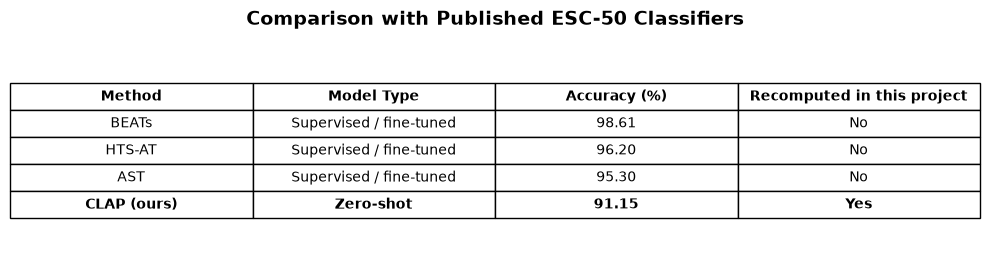

Saved figure to: ../outputs/figures/published_classifier_comparison_table.png


In [21]:
# ============================================================
# 21- Clean table figure for report / presentation
# ============================================================

table_df = published_results[
    ["Method", "Model Type", "Accuracy (%)", "Recomputed in this project"]
].copy()

# Round accuracy values to 2 decimal places
table_df["Accuracy (%)"] = table_df["Accuracy (%)"].map(lambda x: f"{x:.2f}")

fig, ax = plt.subplots(figsize=(10, 2.8))
ax.axis("off")

table = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

# Header styling
for col in range(len(table_df.columns)):
    table[(0, col)].set_text_props(weight="bold")

# Highlight CLAP row
clap_row_index = table_df.index[table_df["Method"] == "CLAP (ours)"][0] + 1
for col in range(len(table_df.columns)):
    table[(clap_row_index, col)].set_text_props(weight="bold")

plt.title(
    "Comparison with Published ESC-50 Classifiers",
    fontsize=14,
    fontweight="bold",
    pad=12
)

plt.tight_layout()

fig_path = FIG_DIR / "published_classifier_comparison_table.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {fig_path}")

## 15. Results Summary

Consolidate the principal experimental results directly from the computed benchmark outputs.


In [ ]:
baseline_accuracy = results_df.loc[
    results_df["strategy"] == "class_only",
    "top1_accuracy"
].iloc[0]

topk_lookup = dict(
    zip(
        topk_df["Top-k"],
        topk_df["Accuracy (%)"]
    )
)

results_summary = {
    "Best prompt strategy": STRATEGY_DISPLAY_NAMES.get(
        best_strategy,
        best_strategy
    ),
    "Best prompt template": best_template,
    "Best Top-1 accuracy (%)": best_accuracy * 100,
    "Class-only baseline (%)": baseline_accuracy * 100,
    "Improvement (percentage points)": (
        best_accuracy - baseline_accuracy
    ) * 100,
    "Top-2 accuracy (%)": topk_lookup["Top-2"],
    "Top-5 accuracy (%)": topk_lookup["Top-5"],
    "Top-10 accuracy (%)": topk_lookup["Top-10"],
}

summary_df = pd.DataFrame(
    results_summary.items(),
    columns=["Metric", "Value"]
)

display(summary_df)

summary_path = TABLE_DIR / "results_summary.csv"
summary_df.to_csv(
    summary_path,
    index=False
)

print("Saved:", summary_path)
